In [1]:
# IMPORT LIBRARIES
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from wordcloud import WordCloud

#nlp
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

#display 
pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries Loaded Successfully


[nltk_data] Downloading package stopwords to /home/sahil-
[nltk_data]     gaund/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# LOAD DATASET
df = pd.read_csv("/home/sahil-gaund/Desktop/scamshield-ai/datasets/raw/sms_spam.csv")

df.head()

,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


In [4]:
# Shape 
print("Dataset Shape:", df.shape)

#info
df.info()

#missing valuess
print(df.isnull().sum())

Dataset Shape: (10961, 2)
<class 'pandas.DataFrame'>
RangeIndex: 10961 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  10961 non-null  str  
 1   text    10961 non-null  str  
dtypes: str(2)
memory usage: 5.7 MB
target    0
text      0
dtype: int64


In [5]:
df.columns

Index(['target', 'text'], dtype='str')

In [6]:
df.head()

,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


In [9]:
#rename columns
df = df[['target', 'text']]

df.columns = ['label', 'message']

df.head()

,label,message
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


label
ham     8555
spam    2406
Name: count, dtype: int64


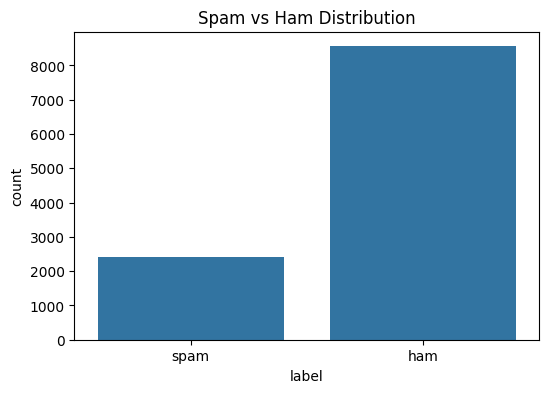

In [10]:
# Count labels
print(df['label'].value_counts())

# Visualization
plt.figure(figsize=(6,4))

sns.countplot(x=df['label'])

plt.title("Spam vs Ham Distribution")
plt.show()

In [11]:
#remove duplicates
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (10961, 2)
After: (10287, 2)


In [13]:
#text length analysis 
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df.head()

,label,message,char_count,word_count
0,spam,Congratulations! You've been selected for a lu...,90,13
1,spam,URGENT: Your account has been compromised. Cli...,89,13
2,spam,You've won a free iPhone! Claim your prize by ...,72,14
3,spam,Act now and receive a 50% discount on all purc...,72,13
4,spam,Important notice: Your subscription will expir...,94,13


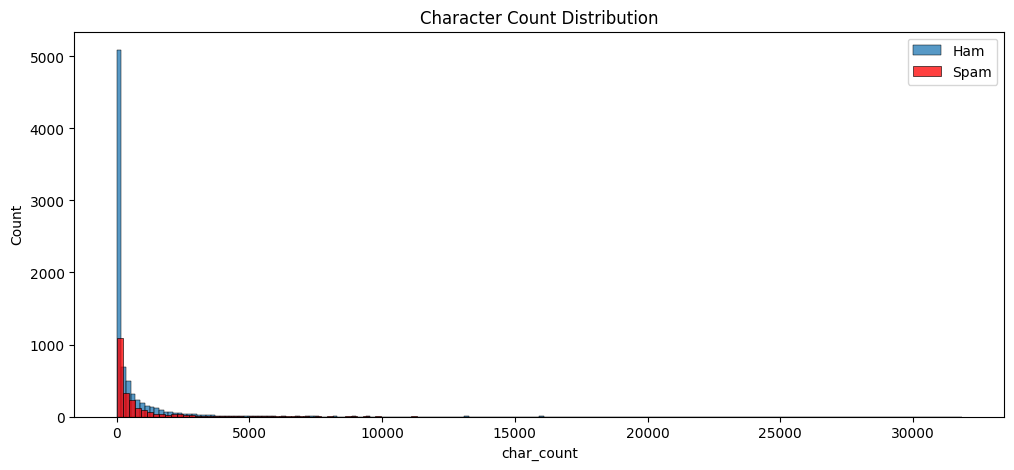

In [14]:
#length distribution
plt.figure(figsize=(12,5))

sns.histplot(df[df['label']=='ham']['char_count'], label='Ham')

sns.histplot(df[df['label']=='spam']['char_count'], color='red', label='Spam')

plt.legend()

plt.title("Character Count Distribution")

plt.show()

In [15]:
#Common Spam Words
spam_words = []

for msg in df[df['label']=='spam']['message']:
    
    for word in msg.lower().split():
        
        spam_words.append(word)

from collections import Counter

common_words = Counter(spam_words).most_common(20)

common_df = pd.DataFrame(common_words, columns=['word', 'count'])

common_df

,word,count
0,.,19403
1,",",11201
2,-,7989
3,the,7564
4,to,5928
5,/,5697
6,and,5121
7,of,4623
8,:,4602
9,a,4204


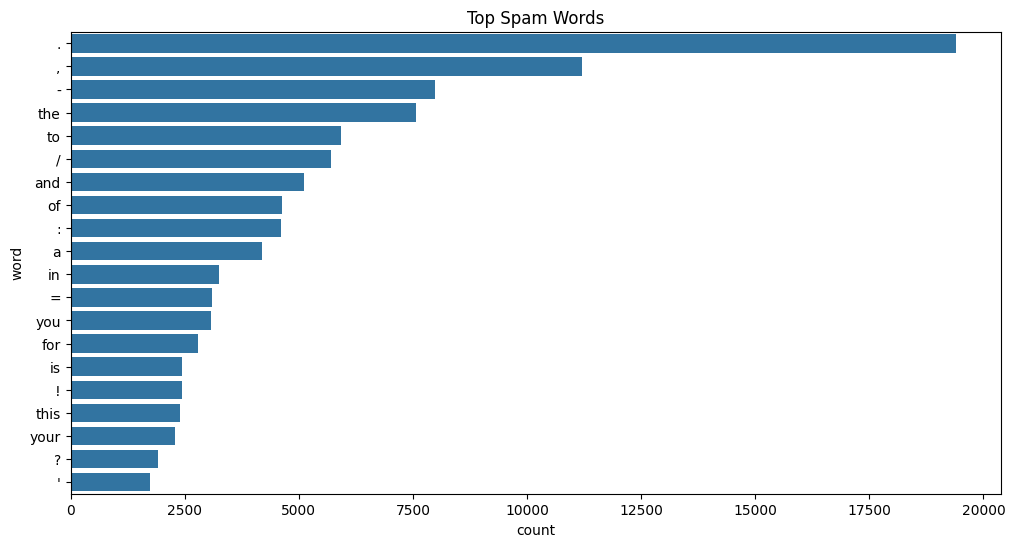

In [16]:
#Plot Common Words
plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='word',
    data=common_df
)

plt.title("Top Spam Words")

plt.show()

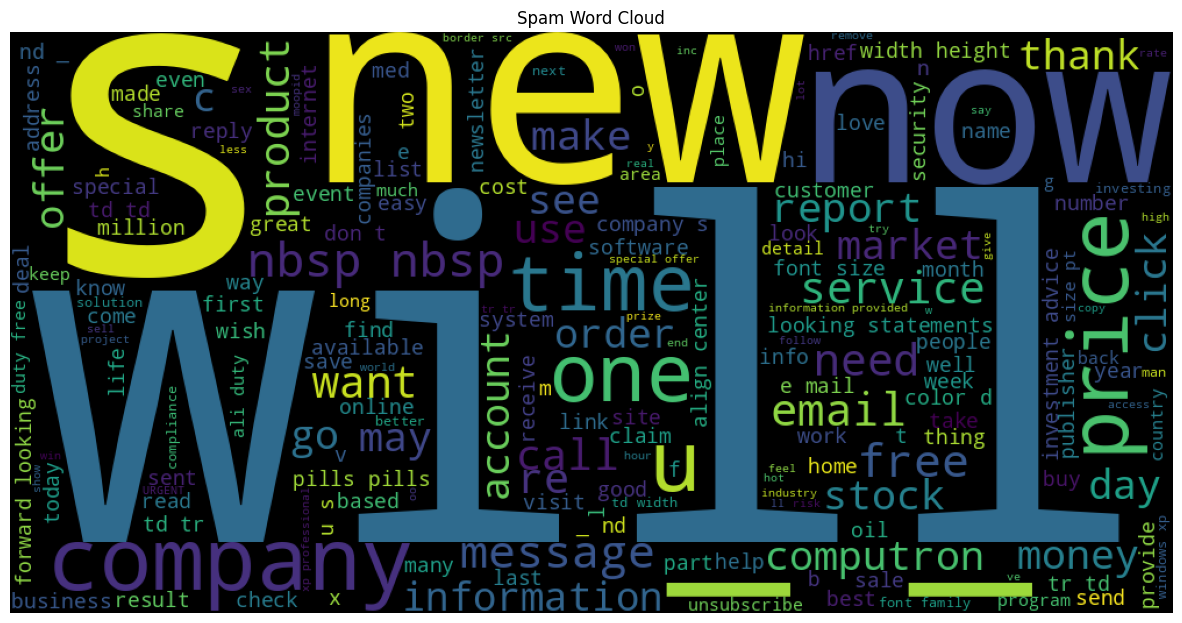

In [17]:
#word cloud 
spam_text = " ".join(df[df['label']=='spam']['message'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(spam_text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Spam Word Cloud")

plt.show()